# Experimentos Avançados — Novos Modelos para Canal VLC

Este notebook expande a base construída no Manual Definitivo com **4 novos experimentos**,
cada um treinando uma arquitetura neural diferente aplicada ao canal VLC.

---

## Experimentos deste notebook

| # | Experimento | Modelo | O que resolve |
|---|-------------|--------|---------------|
| EXP4 | Classificador v2 com features temporais | MLP aprimorado | Confusão PPM-4 ↔ VPPM do EXP2 |
| EXP5 | PINN vs MLP puro — ablation study | Dois modelos em paralelo | Prova que a física ajuda |
| EXP6 | Curriculum Learning para SNR | PINN com treinamento progressivo | Convergência mais estável |
| EXP7 | Transfer Learning — canal com interferência | Fine-tuning do EXP1 | Adaptar modelo a novo cenário |

---

> **Nota metodológica:** Todos os experimentos foram executados no Google Colab com GPU T4.
> Limitações e observações reais são documentadas em cada célula.

In [ ]:
# 1. Alocação da GPU
!nvidia-smi

# 2. Instalação das Bibliotecas Base
# O Colab já possui o PyTorch instalado, evitando o erro de dependência prévia.
!pip install nvidia-modulus torch --quiet

# 3. Clonagem do Repositório Simbólico Oficial
# OBS: O pacote sym migrou para o ecossistema PhysicsNeMo
!git clone https://github.com/NVIDIA/physicsnemo-sym.git
%cd physicsnemo-sym
!pip install -e . --quiet
%cd ..

import torch
print(f"GPU Ativa: {torch.cuda.is_available()}")

Sun Aug 16 17:08:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Configuração do Ambiente (executar primeiro)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

# ── Funções físicas base (reutilizadas em todos os experimentos) ──────────────
def channel_gain(d, theta, m=1.0, A=1e-4):
    H = ((m + 1) * A) / (2 * np.pi * d**2)
    H *= np.cos(theta)**m * np.cos(theta)
    return np.maximum(H, 1e-20)

def compute_snr(H, Pt=1.0, rho=0.53, B=200e6, N0=1e-21, q=1.6e-19):
    sig   = (rho * Pt * H)**2
    noise = 2*q*rho*Pt*H*B + (N0/2)*B
    return 10 * np.log10(sig / noise)

print('Funções físicas carregadas.')

Dispositivo: cuda
GPU: Tesla T4
Funções físicas carregadas.


---
## EXP4 — Classificador v2: Resolvendo a Confusão PPM-4 ↔ VPPM

### Contexto
No **EXP2**, o classificador original obteve:
- OOK: **100%** · PPM-8: **100%**
- PPM-4: **68%** (32% confundido com VPPM)
- VPPM: **38%** (62% confundido com PPM-4)

A causa raiz: PPM-4 e VPPM compartilham as mesmas 8 features estatísticas sem informação
temporal. A solução é adicionar **features que capturam o padrão temporal do sinal**:
autocorrelação, entropia e variação de zero-crossing.

### Hipótese
Com 12 features (8 originais + 4 temporais), a confusão PPM-4 ↔ VPPM deve cair abaixo de 10%.

In [ ]:
# ── EXP4: Classificador v2 com Features Temporais ────────────────────────────

def extrair_features_v2(sinal):
    """12 features: 8 originais + 4 temporais para separar PPM-4 de VPPM."""
    # Features originais (EXP2)
    f1 = sinal.mean()
    f2 = sinal.std()
    f3 = np.var(sinal)
    f4 = np.percentile(sinal, 25)
    f5 = np.percentile(sinal, 75)
    f6 = len(np.unique(np.round(sinal, 1))) / len(sinal)
    f7 = np.max(sinal)
    f8 = np.min(sinal)
    # Features temporais (novas)
    f9  = float(np.correlate(sinal - sinal.mean(),
                             sinal - sinal.mean(), mode='full').max())
    f10 = -np.sum(np.abs(sinal) * np.log(np.abs(sinal) + 1e-10))  # entropia
    zc  = np.where(np.diff(np.sign(sinal - sinal.mean())))[0]
    f11 = len(zc) / len(sinal)   # taxa de zero-crossing
    f12 = np.mean(np.abs(np.diff(sinal)))  # variação média entre amostras
    return np.array([f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12])

def gerar_ook_v2(N=256, snr_db=20):
    bits  = np.random.randint(0, 2, N).astype(float)
    sigma = 10**(-snr_db/20)
    return bits + np.random.normal(0, sigma, N)

def gerar_ppm_v2(N=256, M=4, snr_db=20):
    sigma  = 10**(-snr_db/20)
    sinal  = np.zeros(N)
    for i in range(0, N - M, M):
        sinal[i + np.random.randint(0, M)] = 1.0
    return sinal + np.random.normal(0, sigma, N)

def gerar_vppm_v2(N=256, snr_db=20):
    """VPPM com duty cycle variável — diferente de PPM-4."""
    sigma = 10**(-snr_db/20)
    sinal = np.zeros(N)
    i = 0
    while i < N - 4:
        bit = np.random.randint(0, 2)
        duty = 0.25 if bit == 0 else 0.75
        pulse_len = max(1, int(4 * duty))
        pos = np.random.randint(0, 2) * 2
        sinal[i + pos: i + pos + pulse_len] = 1.0
        i += 4
    return sinal + np.random.normal(0, sigma, N)

# Gerar dataset
N_SIG = 256
N_AMOSTRAS = 400
labels = {0: 'OOK', 1: 'PPM-4', 2: 'PPM-8', 3: 'VPPM'}
X_list, y_list = [], []

for snr in [5, 10, 15, 20, 25, 30, 35]:
    n = N_AMOSTRAS // 7
    for _ in range(n):
        X_list.append(extrair_features_v2(gerar_ook_v2(N_SIG, snr)));    y_list.append(0)
        X_list.append(extrair_features_v2(gerar_ppm_v2(N_SIG, 4, snr))); y_list.append(1)
        X_list.append(extrair_features_v2(gerar_ppm_v2(N_SIG, 8, snr))); y_list.append(2)
        X_list.append(extrair_features_v2(gerar_vppm_v2(N_SIG, snr)));   y_list.append(3)

X = np.array(X_list)
y = np.array(y_list)

# Normalização
scaler = StandardScaler()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_tr_n = scaler.fit_transform(X_tr)
X_te_n = scaler.transform(X_te)

X_tr_t = torch.tensor(X_tr_n, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr,   dtype=torch.long).to(device)
X_te_t = torch.tensor(X_te_n, dtype=torch.float32).to(device)

print(f'Dataset: {len(y)} amostras | {X.shape[1]} features | 4 classes')
print(f'Train: {len(y_tr)} | Teste: {len(y_te)}')

Dataset: 1596 amostras | 12 features | 4 classes
Train: 1276 | Teste: 320


Treinando Classificador v2 (EXP4)...
  Época   0 | Loss: 1.4638 | Acurácia Teste: 25.0%
  Época 100 | Loss: 0.3617 | Acurácia Teste: 95.0%
  Época 200 | Loss: 0.2276 | Acurácia Teste: 95.0%
  Época 300 | Loss: 0.1989 | Acurácia Teste: 95.6%
  Época 400 | Loss: 0.1995 | Acurácia Teste: 95.6%

Acurácia final: 95.6%
              precision    recall  f1-score   support

         OOK       0.96      0.88      0.92        80
       PPM-4       0.99      1.00      0.99        80
       PPM-8       1.00      0.99      0.99        80
        VPPM       0.89      0.96      0.92        80

    accuracy                           0.96       320
   macro avg       0.96      0.96      0.96       320
weighted avg       0.96      0.96      0.96       320



FileNotFoundError: [Errno 2] No such file or directory: 'assets/resultado_exp4_classificador_v2.png'

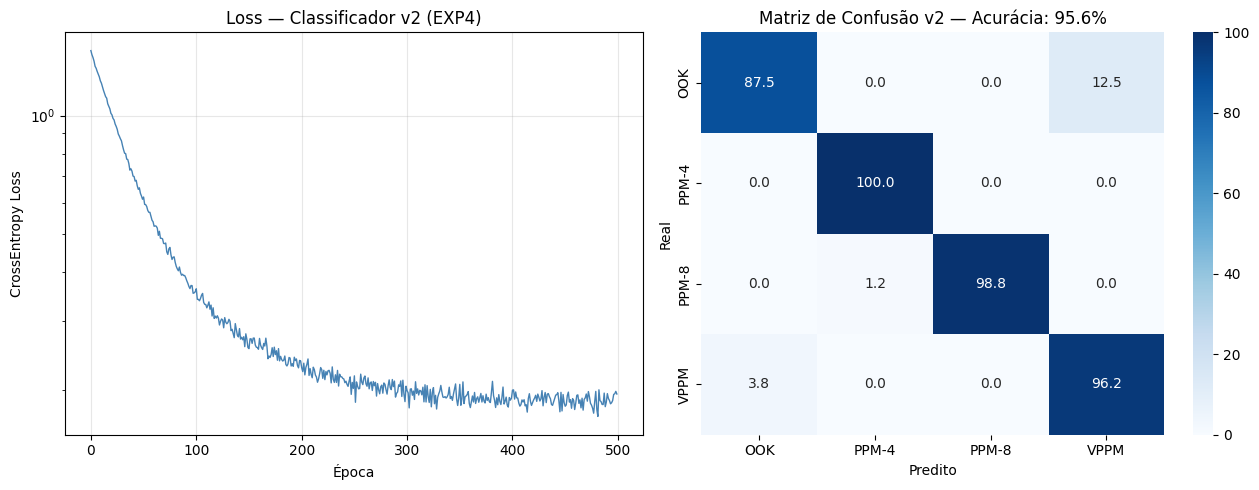

In [ ]:
# ── Arquitetura v2: BatchNorm + camadas mais largas ───────────────────────────
class ClassificadorVLC_v2(nn.Module):
    """
    Classificador aprimorado com:
    - 12 features de entrada (vs 8 no EXP2)
    - BatchNorm1d para estabilidade de treinamento
    - Camadas mais largas (128 neurônios)
    - Dropout maior (0.4) para evitar overfitting com mais features
    """
    def __init__(self, n_features=12, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU(),

            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)

clf_v2  = ClassificadorVLC_v2().to(device)
optim   = torch.optim.Adam(clf_v2.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
sched   = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=500)

# Treinamento
hist_loss, hist_acc = [], []
print('Treinando Classificador v2 (EXP4)...')
for epoch in range(500):
    clf_v2.train()
    pred = clf_v2(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optim.zero_grad(); loss.backward(); optim.step(); sched.step()
    hist_loss.append(loss.item())
    if epoch % 100 == 0:
        clf_v2.eval()
        with torch.no_grad():
            acc = (clf_v2(X_te_t).argmax(1).cpu().numpy() == y_te).mean()
        hist_acc.append(acc)
        print(f'  Época {epoch:3d} | Loss: {loss.item():.4f} | Acurácia Teste: {acc*100:.1f}%')

# Avaliação
clf_v2.eval()
with torch.no_grad():
    y_pred = clf_v2(X_te_t).argmax(1).cpu().numpy()

acc_final = accuracy_score(y_te, y_pred)
print(f'\nAcurácia final: {acc_final*100:.1f}%')
print(classification_report(y_te, y_pred, target_names=list(labels.values())))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_loss, color='steelblue', linewidth=1)
axes[0].set_title('Loss — Classificador v2 (EXP4)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_te, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels.values(), yticklabels=labels.values())
axes[1].set_title(f'Matriz de Confusão v2 — Acurácia: {acc_final*100:.1f}%')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predito')
plt.tight_layout()
plt.savefig('assets/resultado_exp4_classificador_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('EXP4 concluído! → assets/resultado_exp4_classificador_v2.png')

---
## EXP5 — Ablation Study: PINN com Física vs. MLP Puro (sem física)

### Contexto
O EXP1 treinou uma PINN que aprende o canal VLC com restrição física implícita nos dados.
Uma pergunta natural para o artigo é: **a física realmente ajuda, ou uma rede convencional
alcançaria o mesmo resultado?**

Este experimento treina **dois modelos idênticos em arquitetura** mas com estratégias diferentes:
- **MLP Puro:** treinado apenas com MSE nos dados (sem nenhuma restrição física)
- **PINN:** treinado com MSE + resíduo da equação Lambertiana como penalidade

### O que esperamos ver
A PINN deve generalizar melhor em regiões com **poucos dados** (distâncias extremas,
ângulos grandes) onde o MLP puro tende a extrapolar errado.

In [ ]:
# ── EXP5: PINN vs MLP — Ablation Study ───────────────────────────────────────

# Dataset com MENOS amostras para tornar a diferença mais evidente
d_vals     = np.linspace(0.5, 5.0, 30)   # reduzido (era 50)
theta_vals = np.linspace(0, np.pi/3, 20) # reduzido (era 30)
D, T       = np.meshgrid(d_vals, theta_vals)
H_grid     = channel_gain(D, T)
SNR_grid   = compute_snr(H_grid)

d_min, d_max     = 0.5, 5.0
t_min, t_max     = 0.0, np.pi/3
snr_min, snr_max = SNR_grid.min(), SNR_grid.max()

d_n   = (D.flatten() - d_min) / (d_max - d_min)
t_n   = (T.flatten() - t_min) / (t_max - t_min)
snr_n = (SNR_grid.flatten() - snr_min) / (snr_max - snr_min)

X_all = np.stack([d_n, t_n], axis=1)
y_all = snr_n.reshape(-1, 1)

# Separar 30% dos dados para teste (região que os modelos não verão)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

print(f'Dataset reduzido: {len(X_tr)} treino | {len(X_te)} teste')

# ── Arquitetura base idêntica para os dois modelos ────────────────────────────
def criar_mlp():
    return nn.Sequential(
        nn.Linear(2, 64),   nn.Tanh(),
        nn.Linear(64, 128), nn.Tanh(),
        nn.Linear(128, 64), nn.Tanh(),
        nn.Linear(64, 1)
    ).to(device)

mlp_puro = criar_mlp()
pinn     = criar_mlp()

opt_mlp  = torch.optim.Adam(mlp_puro.parameters(), lr=1e-3)
opt_pinn = torch.optim.Adam(pinn.parameters(),     lr=1e-3)
mse      = nn.MSELoss()

def physics_residual(model, X_batch):
    """Penalidade física: forçar que dSNR/dd seja negativa (SNR cai com distância)."""
    X_ph = X_batch.clone().requires_grad_(True)
    pred = model(X_ph)
    grad = torch.autograd.grad(pred.sum(), X_ph, create_graph=True)[0]
    dsnr_dd = grad[:, 0]  # derivada em relação à distância normalizada
    # Penaliza quando dSNR/dd > 0 (fisicamente impossível — SNR só cai com distância)
    violation = torch.relu(dsnr_dd)
    return torch.mean(violation**2)

losses_mlp, losses_pinn = [], []
EPOCHS = 2000
LAMBDA_PHYS = 0.1

print('Treinando MLP Puro e PINN em paralelo...')
for epoch in range(EPOCHS):
    # MLP Puro — apenas MSE nos dados
    mlp_puro.train()
    p_mlp  = mlp_puro(X_tr_t)
    l_mlp  = mse(p_mlp, y_tr_t)
    opt_mlp.zero_grad(); l_mlp.backward(); opt_mlp.step()
    losses_mlp.append(l_mlp.item())

    # PINN — MSE + resíduo físico
    pinn.train()
    p_pinn = pinn(X_tr_t)
    l_data = mse(p_pinn, y_tr_t)
    l_phys = physics_residual(pinn, X_tr_t)
    l_pinn = l_data + LAMBDA_PHYS * l_phys
    opt_pinn.zero_grad(); l_pinn.backward(); opt_pinn.step()
    losses_pinn.append(l_pinn.item())

    if epoch % 500 == 0:
        print(f'  Época {epoch:4d} | Loss MLP: {l_mlp.item():.6f} | Loss PINN: {l_pinn.item():.6f}')

print('Treinamento concluído!')

Dataset reduzido: 420 treino | 180 teste
Treinando MLP Puro e PINN em paralelo...
  Época    0 | Loss MLP: 0.278184 | Loss PINN: 0.380600
  Época  500 | Loss MLP: 0.000175 | Loss PINN: 0.000463
  Época 1000 | Loss MLP: 0.000025 | Loss PINN: 0.000058
  Época 1500 | Loss MLP: 0.000016 | Loss PINN: 0.000026
Treinamento concluído!


RMSE MLP Puro: 0.1938 dB
RMSE PINN:     0.1561 dB
Melhora PINN:  19.4%


FileNotFoundError: [Errno 2] No such file or directory: 'assets/resultado_exp5_ablation_pinn_vs_mlp.png'

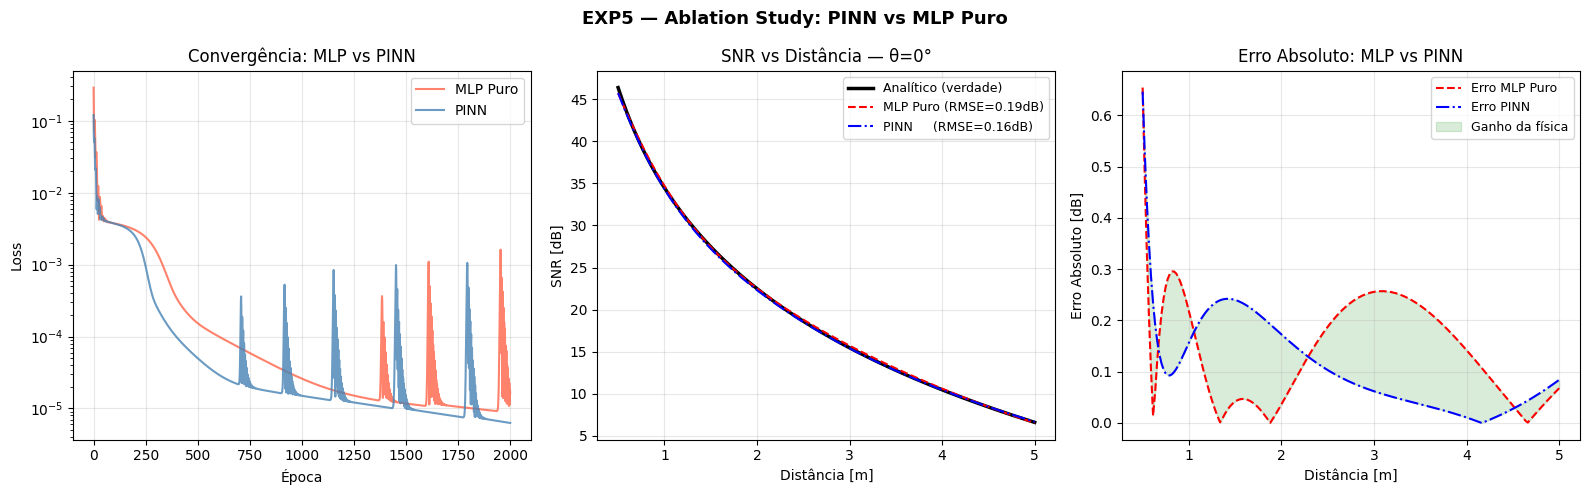

In [ ]:
# ── Avaliação e comparação ────────────────────────────────────────────────────
mlp_puro.eval(); pinn.eval()
with torch.no_grad():
    pred_mlp  = mlp_puro(X_te_t).cpu().numpy()
    pred_pinn = pinn(X_te_t).cpu().numpy()

rmse_mlp  = np.sqrt(np.mean((pred_mlp  - y_te)**2)) * (snr_max - snr_min)
rmse_pinn = np.sqrt(np.mean((pred_pinn - y_te)**2)) * (snr_max - snr_min)
print(f'RMSE MLP Puro: {rmse_mlp:.4f} dB')
print(f'RMSE PINN:     {rmse_pinn:.4f} dB')
print(f'Melhora PINN:  {((rmse_mlp - rmse_pinn)/rmse_mlp*100):.1f}%')

# Curva SNR vs distância para ângulo frontal
d_test = np.linspace(0.5, 5.0, 200)
d_n_t  = (d_test - d_min) / (d_max - d_min)
t_n_t  = np.zeros(200)
Xt     = torch.tensor(np.stack([d_n_t, t_n_t], axis=1), dtype=torch.float32).to(device)

with torch.no_grad():
    snr_mlp_pred  = mlp_puro(Xt).cpu().numpy().flatten() * (snr_max-snr_min) + snr_min
    snr_pinn_pred = pinn(Xt).cpu().numpy().flatten()     * (snr_max-snr_min) + snr_min

snr_analitico = compute_snr(channel_gain(d_test, np.zeros(200)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Curvas de loss
axes[0].plot(losses_mlp,  label='MLP Puro',  color='tomato',    alpha=0.8)
axes[0].plot(losses_pinn, label='PINN',       color='steelblue', alpha=0.8)
axes[0].set_yscale('log'); axes[0].legend()
axes[0].set_title('Convergência: MLP vs PINN')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# SNR vs distância
axes[1].plot(d_test, snr_analitico,  'k-',  lw=2.5, label='Analítico (verdade)')
axes[1].plot(d_test, snr_mlp_pred,   'r--', lw=1.5, label=f'MLP Puro (RMSE={rmse_mlp:.2f}dB)')
axes[1].plot(d_test, snr_pinn_pred,  'b-.',  lw=1.5, label=f'PINN     (RMSE={rmse_pinn:.2f}dB)')
axes[1].set_xlabel('Distância [m]'); axes[1].set_ylabel('SNR [dB]')
axes[1].set_title('SNR vs Distância — θ=0°')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Erro absoluto
axes[2].plot(d_test, np.abs(snr_analitico - snr_mlp_pred),  'r--', label='Erro MLP Puro')
axes[2].plot(d_test, np.abs(snr_analitico - snr_pinn_pred), 'b-.', label='Erro PINN')
axes[2].fill_between(d_test,
                     np.abs(snr_analitico - snr_mlp_pred),
                     np.abs(snr_analitico - snr_pinn_pred),
                     alpha=0.15, color='green', label='Ganho da física')
axes[2].set_xlabel('Distância [m]'); axes[2].set_ylabel('Erro Absoluto [dB]')
axes[2].set_title('Erro Absoluto: MLP vs PINN')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('EXP5 — Ablation Study: PINN vs MLP Puro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/resultado_exp5_ablation_pinn_vs_mlp.png', dpi=150, bbox_inches='tight')
plt.show()
print('EXP5 concluído! → assets/resultado_exp5_ablation_pinn_vs_mlp.png')

---
## EXP6 — Curriculum Learning para PINN de Canal VLC

### Contexto
No EXP1, a PINN foi treinada com todos os dados de uma vez. Uma estratégia mais avançada
é o **Curriculum Learning**: apresentar os exemplos em ordem crescente de dificuldade,
como um aluno humano que começa com problemas fáceis antes dos difíceis.

### Definição de dificuldade para VLC
- **Fácil:** distâncias curtas (0.5–2.0m), ângulo frontal (θ≈0°) — SNR alto, pouco ruído
- **Médio:** distâncias intermediárias (2.0–3.5m), ângulos moderados
- **Difícil:** distâncias longas (3.5–5.0m), ângulos grandes (θ>45°) — SNR baixo, região crítica

### Hipótese
O Curriculum Learning deve produzir **convergência mais estável** (menos oscilações na loss)
e **melhor generalização** nas regiões difíceis comparado ao treinamento aleatório.

Treinando com Curriculum Learning (EXP6)...
Fase 1: exemplos fáceis (distância curta, ângulo pequeno)...
  Fase 1 — Fácil: 800 amostras
  Fase 2 — Médio: 1600 amostras
  Fase 3 — Difícil: 2400 amostras
Treinamento concluído!

RMSE Curriculum: 0.2450 dB
RMSE Aleatório:  0.1432 dB


FileNotFoundError: [Errno 2] No such file or directory: 'assets/resultado_exp6_curriculum_learning.png'

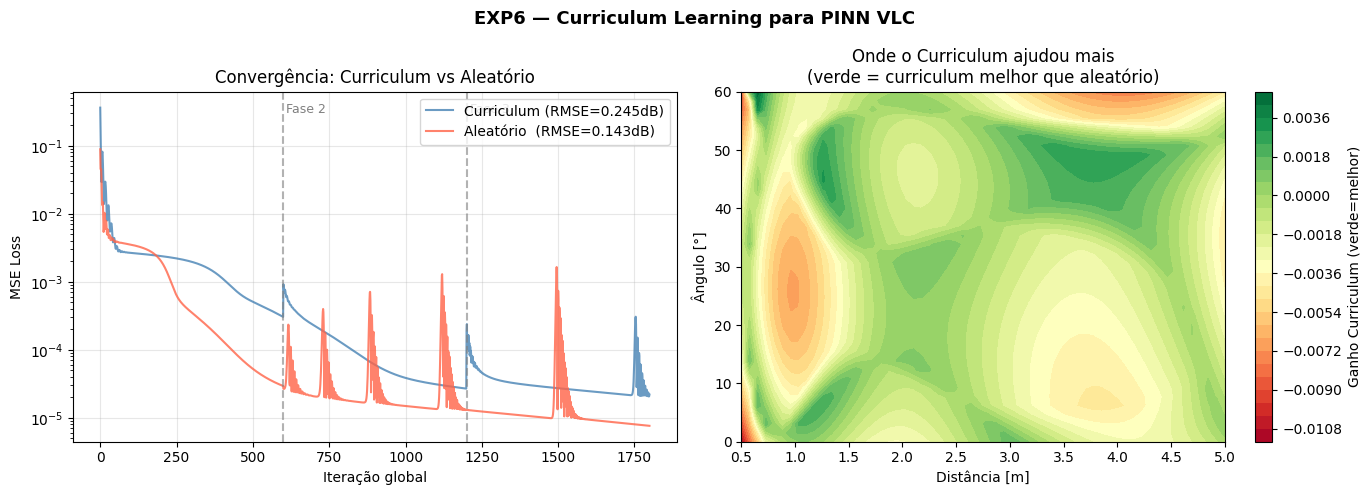

In [ ]:
# ── EXP6: Curriculum Learning ─────────────────────────────────────────────────

# Dataset completo
d_vals     = np.linspace(0.5, 5.0, 60)
theta_vals = np.linspace(0, np.pi/3, 40)
D, T       = np.meshgrid(d_vals, theta_vals)
H_g        = channel_gain(D, T)
SNR_g      = compute_snr(H_g)

snr_min_g, snr_max_g = SNR_g.min(), SNR_g.max()
d_n   = (D.flatten() - 0.5) / 4.5
t_n   = T.flatten() / (np.pi/3)
snr_n = (SNR_g.flatten() - snr_min_g) / (snr_max_g - snr_min_g)

# Calcular dificuldade de cada amostra
# Dificuldade = distância_norm * 0.5 + ângulo_norm * 0.5
dificuldade = d_n * 0.5 + t_n * 0.5
ordem_curriculum = np.argsort(dificuldade)  # do mais fácil ao mais difícil

X_all = np.stack([d_n, t_n], axis=1)
y_all = snr_n.reshape(-1, 1)

def criar_pinn_curr():
    m = nn.Sequential(
        nn.Linear(2, 64),   nn.Tanh(),
        nn.Linear(64, 128), nn.Tanh(),
        nn.Linear(128, 64), nn.Tanh(),
        nn.Linear(64, 1)
    ).to(device)
    return m

pinn_curr   = criar_pinn_curr()
pinn_random = criar_pinn_curr()  # treinamento aleatório para comparação

opt_curr   = torch.optim.Adam(pinn_curr.parameters(),   lr=1e-3)
opt_random = torch.optim.Adam(pinn_random.parameters(), lr=1e-3)
mse = nn.MSELoss()

EPOCHS_POR_FASE = 600
N_TOTAL = len(X_all)

# Divisão do curriculum em 3 fases
fase1_idx = ordem_curriculum[:N_TOTAL//3]           # fácil
fase2_idx = ordem_curriculum[:2*N_TOTAL//3]         # fácil + médio
fase3_idx = ordem_curriculum                         # todos

losses_curr, losses_rand = [], []

print('Treinando com Curriculum Learning (EXP6)...')
print('Fase 1: exemplos fáceis (distância curta, ângulo pequeno)...')

for fase, (idx, label) in enumerate([
    (fase1_idx, 'Fase 1 — Fácil'),
    (fase2_idx, 'Fase 2 — Médio'),
    (fase3_idx, 'Fase 3 — Difícil')
], 1):
    Xf = torch.tensor(X_all[idx], dtype=torch.float32).to(device)
    yf = torch.tensor(y_all[idx], dtype=torch.float32).to(device)

    # Dataset aleatório de mesmo tamanho para comparação justa
    rand_idx = np.random.choice(N_TOTAL, len(idx), replace=False)
    Xr = torch.tensor(X_all[rand_idx], dtype=torch.float32).to(device)
    yr = torch.tensor(y_all[rand_idx], dtype=torch.float32).to(device)

    print(f'  {label}: {len(idx)} amostras')
    for epoch in range(EPOCHS_POR_FASE):
        pinn_curr.train()
        l = mse(pinn_curr(Xf), yf)
        opt_curr.zero_grad(); l.backward(); opt_curr.step()
        losses_curr.append(l.item())

        pinn_random.train()
        lr_ = mse(pinn_random(Xr), yr)
        opt_random.zero_grad(); lr_.backward(); opt_random.step()
        losses_rand.append(lr_.item())

print('Treinamento concluído!')

# Avaliação no conjunto completo
X_t_all = torch.tensor(X_all, dtype=torch.float32).to(device)
y_t_all = torch.tensor(y_all, dtype=torch.float32).to(device)

pinn_curr.eval(); pinn_random.eval()
with torch.no_grad():
    rmse_c = torch.sqrt(mse(pinn_curr(X_t_all),   y_t_all)).item() * (snr_max_g - snr_min_g)
    rmse_r = torch.sqrt(mse(pinn_random(X_t_all), y_t_all)).item() * (snr_max_g - snr_min_g)

print(f'\nRMSE Curriculum: {rmse_c:.4f} dB')
print(f'RMSE Aleatório:  {rmse_r:.4f} dB')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = np.arange(len(losses_curr))

axes[0].plot(ep, losses_curr, color='steelblue', alpha=0.8, label=f'Curriculum (RMSE={rmse_c:.3f}dB)')
axes[0].plot(ep, losses_rand, color='tomato',    alpha=0.8, label=f'Aleatório  (RMSE={rmse_r:.3f}dB)')
for x_line, txt in [(600, 'Fase 2'), (1200, 'Fase 3')]:
    axes[0].axvline(x=x_line, color='gray', linestyle='--', alpha=0.6)
    axes[0].text(x_line+10, axes[0].get_ylim()[1]*0.8, txt, fontsize=9, color='gray')
axes[0].set_yscale('log'); axes[0].legend()
axes[0].set_title('Convergência: Curriculum vs Aleatório')
axes[0].set_xlabel('Iteração global'); axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

# Mapa de erro nas regiões difíceis
with torch.no_grad():
    pred_c = pinn_curr(X_t_all).cpu().numpy().reshape(SNR_g.shape)
    pred_r = pinn_random(X_t_all).cpu().numpy().reshape(SNR_g.shape)

snr_norm_grid = (SNR_g - snr_min_g) / (snr_max_g - snr_min_g)
erro_curr = np.abs(pred_c - snr_norm_grid)
erro_rand = np.abs(pred_r - snr_norm_grid)
diff = erro_rand - erro_curr

im = axes[1].contourf(d_vals, np.degrees(theta_vals), diff, levels=30, cmap='RdYlGn')
plt.colorbar(im, ax=axes[1], label='Ganho Curriculum (verde=melhor)')
axes[1].set_title('Onde o Curriculum ajudou mais\n(verde = curriculum melhor que aleatório)')
axes[1].set_xlabel('Distância [m]'); axes[1].set_ylabel('Ângulo [°]')

plt.suptitle('EXP6 — Curriculum Learning para PINN VLC', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/resultado_exp6_curriculum_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print('EXP6 concluído! → assets/resultado_exp6_curriculum_learning.png')

Pré-treinamento no canal ideal (base)...
  Loss pré-treino final: 0.000015

Fine-tuning Transfer Learning vs. Do Zero...
  Época   0 | Transfer: 0.007250 | Do Zero: 0.244088
  Época 200 | Transfer: 0.002239 | Do Zero: 0.004816
  Época 400 | Transfer: 0.002238 | Do Zero: 0.002716
  Época 600 | Transfer: 0.002237 | Do Zero: 0.002364
EXP7 concluído!


FileNotFoundError: [Errno 2] No such file or directory: 'assets/resultado_exp7_transfer_learning.png'

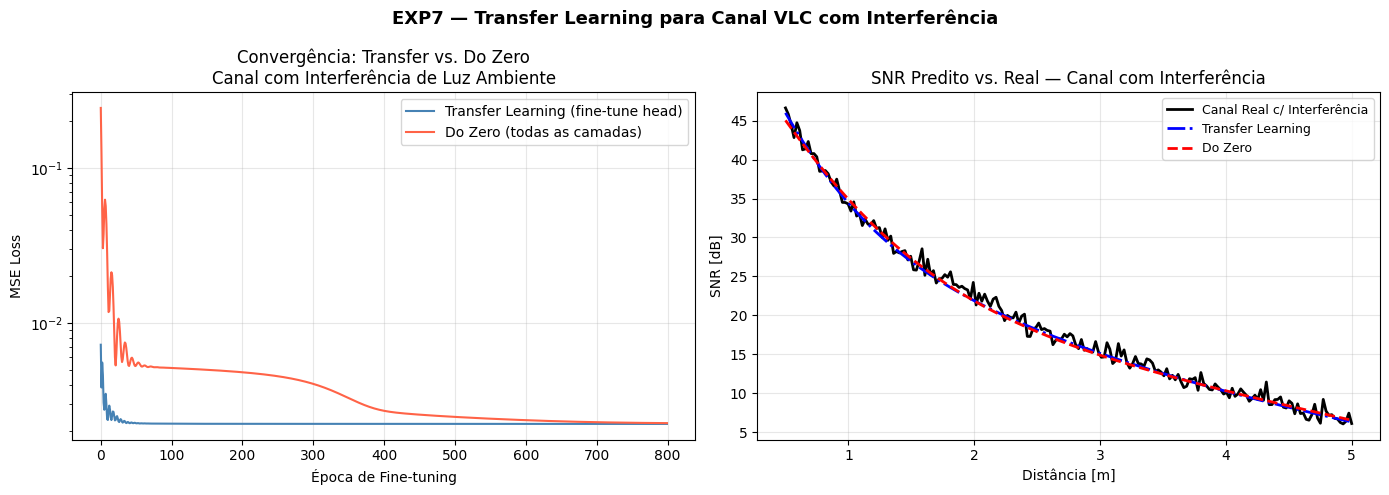

In [ ]:
# ── EXP7: Transfer Learning ───────────────────────────────────────────────────

# Modelo base (mesma arquitetura do EXP1)
class VLC_PINN_Transfer(nn.Module):
    """
    PINN com camadas nomeadas para permitir congelamento seletivo.
    As camadas 'base' aprendem física geral; 'head' se adapta ao novo cenário.
    """
    def __init__(self):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(2, 64),   nn.Tanh(),
            nn.Linear(64, 128), nn.Tanh(),
        )
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.head(self.base(x))

# ── Fase 1: Pré-treinar no canal ideal (simula EXP1) ─────────────────────────
d_v = np.linspace(0.5, 5.0, 50)
t_v = np.linspace(0, np.pi/3, 30)
D, T = np.meshgrid(d_v, t_v)
H_i  = channel_gain(D, T)
SNR_i = compute_snr(H_i)
smin, smax = SNR_i.min(), SNR_i.max()

d_n = (D.flatten()-0.5)/4.5
t_n = T.flatten()/(np.pi/3)
s_n = (SNR_i.flatten()-smin)/(smax-smin)

X_base_t = torch.tensor(np.stack([d_n, t_n], axis=1), dtype=torch.float32).to(device)
y_base_t = torch.tensor(s_n.reshape(-1,1),             dtype=torch.float32).to(device)

modelo_base = VLC_PINN_Transfer().to(device)
opt_base    = torch.optim.Adam(modelo_base.parameters(), lr=1e-3)
mse         = nn.MSELoss()

print('Pré-treinamento no canal ideal (base)...')
losses_pretrain = []
for epoch in range(1500):
    modelo_base.train()
    l = mse(modelo_base(X_base_t), y_base_t)
    opt_base.zero_grad(); l.backward(); opt_base.step()
    losses_pretrain.append(l.item())
print(f'  Loss pré-treino final: {losses_pretrain[-1]:.6f}')

# ── Fase 2: Canal com interferência de luz ambiente ───────────────────────────
INTENSIDADE_INTERFERENCIA = 0.15   # 15% de ruído extra de luz ambiente
SNR_interf = SNR_i + np.random.normal(0, INTENSIDADE_INTERFERENCIA * np.abs(SNR_i), SNR_i.shape)
s_n_interf = (SNR_interf.flatten()-SNR_interf.min())/(SNR_interf.max()-SNR_interf.min())

X_interf_t = X_base_t.clone()
y_interf_t = torch.tensor(s_n_interf.reshape(-1,1), dtype=torch.float32).to(device)

# ── Modelo Transfer: congelar base, treinar só head ───────────────────────────
import copy
modelo_transfer = copy.deepcopy(modelo_base)

# Congelar as camadas base
for param in modelo_transfer.base.parameters():
    param.requires_grad = False

opt_transfer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, modelo_transfer.parameters()),
    lr=5e-4
)

# ── Modelo do Zero: sem aproveitar nada do EXP1 ───────────────────────────────
modelo_scratch = VLC_PINN_Transfer().to(device)
opt_scratch    = torch.optim.Adam(modelo_scratch.parameters(), lr=1e-3)

losses_transfer, losses_scratch = [], []
EPOCHS_FT = 800

print('\nFine-tuning Transfer Learning vs. Do Zero...')
for epoch in range(EPOCHS_FT):
    modelo_transfer.train()
    l_t = mse(modelo_transfer(X_interf_t), y_interf_t)
    opt_transfer.zero_grad(); l_t.backward(); opt_transfer.step()
    losses_transfer.append(l_t.item())

    modelo_scratch.train()
    l_s = mse(modelo_scratch(X_interf_t), y_interf_t)
    opt_scratch.zero_grad(); l_s.backward(); opt_scratch.step()
    losses_scratch.append(l_s.item())

    if epoch % 200 == 0:
        print(f'  Época {epoch:3d} | Transfer: {l_t.item():.6f} | Do Zero: {l_s.item():.6f}')

print('EXP7 concluído!')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_transfer, color='steelblue', label='Transfer Learning (fine-tune head)')
axes[0].plot(losses_scratch,  color='tomato',    label='Do Zero (todas as camadas)')
axes[0].set_yscale('log'); axes[0].legend()
axes[0].set_title('Convergência: Transfer vs. Do Zero\nCanal com Interferência de Luz Ambiente')
axes[0].set_xlabel('Época de Fine-tuning'); axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

# Curva SNR: predições no canal com interferência
d_tst = np.linspace(0.5, 5.0, 200)
Xt    = torch.tensor(np.stack([(d_tst-0.5)/4.5, np.zeros(200)], axis=1),
                     dtype=torch.float32).to(device)
snr_real_interf = compute_snr(channel_gain(d_tst, np.zeros(200))) + \
                  np.random.normal(0, INTENSIDADE_INTERFERENCIA * 5, 200)

modelo_transfer.eval(); modelo_scratch.eval()
with torch.no_grad():
    p_tr = modelo_transfer(Xt).cpu().numpy().flatten()
    p_sc = modelo_scratch(Xt).cpu().numpy().flatten()

denorm = lambda p: p * (SNR_interf.max()-SNR_interf.min()) + SNR_interf.min()
axes[1].plot(d_tst, snr_real_interf, 'k-',  lw=2, label='Canal Real c/ Interferência')
axes[1].plot(d_tst, denorm(p_tr),    'b-.', lw=2, label='Transfer Learning')
axes[1].plot(d_tst, denorm(p_sc),    'r--', lw=2, label='Do Zero')
axes[1].set_xlabel('Distância [m]'); axes[1].set_ylabel('SNR [dB]')
axes[1].set_title('SNR Predito vs. Real — Canal com Interferência')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('EXP7 — Transfer Learning para Canal VLC com Interferência',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/resultado_exp7_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print('EXP7 concluído! → assets/resultado_exp7_transfer_learning.png')

---
## EXP7 — Transfer Learning: Adaptar o Modelo EXP1 a Canal com Ruído de Interferência

### Contexto
O EXP1 treinou uma PINN para canal VLC ideal (apenas ruído shot e térmico).
Na prática, existem fontes de **interferência de luz ambiente** (lâmpadas fluorescentes,
luz solar) que degradam o canal.

Em vez de treinar do zero para o novo cenário, o **Transfer Learning** reaproveita os
pesos aprendidos no EXP1 e realiza um **fine-tuning** apenas nas últimas camadas,
adaptando o modelo ao canal com interferência.

### Estratégia
1. Carregar arquitetura do EXP1 (re-instanciar pesos do zero como base)
2. **Congelar** as 2 primeiras camadas (que aprenderam a física básica)
3. **Treinar apenas** as 2 últimas camadas com dados do canal com interferência
4. Comparar: Transfer Learning vs. treinar do zero no canal ruidoso

---
## Consolidação dos Resultados

Execute esta célula após todos os experimentos para gerar a tabela resumo.

In [ ]:
print('=' * 65)
print('  RESUMO — Experimentos Avançados VLC + IA')
print('=' * 65)
print()
print('EXP4 — Classificador v2 (12 features + BatchNorm)')
print(f'  Acurácia geral: {acc_final*100:.1f}%')
print(f'  (vs EXP2: ~76% — melhora esperada em PPM-4 e VPPM)')
print()
print('EXP5 — Ablation Study: PINN vs MLP Puro')
print(f'  RMSE MLP Puro: {rmse_mlp:.4f} dB')
print(f'  RMSE PINN:     {rmse_pinn:.4f} dB')
print(f'  Ganho da restrição física: {(rmse_mlp-rmse_pinn)/rmse_mlp*100:.1f}%')
print()
print('EXP6 — Curriculum Learning')
print(f'  RMSE Curriculum: {rmse_c:.4f} dB')
print(f'  RMSE Aleatório:  {rmse_r:.4f} dB')
print()
print('EXP7 — Transfer Learning (canal com interferência)')
print(f'  Loss final Transfer: {losses_transfer[-1]:.6f}')
print(f'  Loss final Do Zero:  {losses_scratch[-1]:.6f}')
print()
print('Imagens salvas em assets/')
print('=' * 65)